Characterizing Input Offset
===========================

The Qblox QRM and QRM-RF use analog-to-digital converters (ADCs) to digitize the incoming analog signals. Due to thermal, manufacturing effects or other factors, the digitized signal is not centered around 0V but has a small offset, which we will hereby refer to as input (ADC) offset. This input offset can get demodulated and integrated by the hardware along with the signal. The integrated offset can then show up as oscillations in the result, e.g. during a frequency sweep. In this section we show how to measure and calibrate away this offset to prevent such effects.

Measuring the Offset
--------------------

We will use a simple scope acquisition to determine the mean value of this offset. Before proceeding, please **make sure that there is no DC signal going into** to your QRM.

Setup
-----

First, we are going to import the required packages.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np

In [2]:
from __future__ import annotations

from typing import TYPE_CHECKING, Callable

from qcodes.instrument import find_or_create_instrument

from qblox_instruments import Cluster, ClusterType

if TYPE_CHECKING:
    from qblox_instruments.qcodes_drivers.module import Module

### Scan For Clusters

We scan for the available devices connected via ethernet using the Plug & Play functionality of the Qblox Instruments package (see [Plug & Play](https://qblox-qblox-instruments.readthedocs-hosted.com/en/main/api_reference/tools.html#api-pnp) for more info).

In [3]:
!qblox-pnp list

Devices:
 - 192.168.137.2: cluster_mm 0.9.1 with name "cluster-mm" and serial number 00015_2251_003


In [4]:
cluster_ip = "192.168.137.2"
cluster_name = "cluster0"

### Connect to Cluster

We now make a connection with the Cluster.

In [5]:
cluster = find_or_create_instrument(
    Cluster,
    recreate=True,
    name=cluster_name,
    identifier=cluster_ip,
    dummy_cfg=(
        {
            2: ClusterType.CLUSTER_QCM,
            4: ClusterType.CLUSTER_QRM,
            6: ClusterType.CLUSTER_QCM_RF,
            8: ClusterType.CLUSTER_QRM_RF,
        }
        if cluster_ip is None
        else None
    ),
)

#### Get connected modules

In [6]:
def get_connected_modules(cluster: Cluster, filter_fn: Callable | None = None) -> dict[int, Module]:
    def checked_filter_fn(mod: ClusterType) -> bool:
        if filter_fn is not None:
            return filter_fn(mod)
        return True

    return {
        mod.slot_idx: mod for mod in cluster.modules if mod.present() and checked_filter_fn(mod)
    }

In [11]:
# QRM modules
modules = get_connected_modules(cluster, lambda mod: mod.is_qcm_type and not mod.is_rf_type)

In [12]:
# This uses the module of the correct type with the lowest slot index
module = list(modules.values())[0]

In [13]:
print(modules)
print(module)

{2: <Module: cluster0_module2 of Cluster: cluster0>}
<Module: cluster0_module2 of Cluster: cluster0>


### Reset the Cluster

We reset the Cluster to enter a well-defined state. Note that resetting will clear all stored parameters, so resetting between experiments is usually not desirable.

In [14]:
cluster.reset()
print(cluster.get_system_status())

Status: OKAY, Flags: NONE, Slot flags: NONE


Specify acquisitions
--------------------

We need to specify the acquisitions so that the instrument can allocate the required memory for its acquisition list. In this case we will create 5 acquisition specifications that each create one or multiple bins.

In [15]:
# Acquisitions
acquisitions = {
    "non_weighed": {"num_bins": 10, "index": 0},
    "weighed": {"num_bins": 10, "index": 1},
    "large": {"num_bins": 131072, "index": 2},
    "avg": {"num_bins": 10, "index": 3},
    "single": {"num_bins": 1, "index": 4},
}

In [11]:
# Create a helper function that creates an acquisition program, runs the sequencer and calculates the ADC offsets based on acquired results.


def acquire_scope_and_calc_offsets() -> tuple[float, float]:
    seq_prog = """
        move    1000, R0        #Loop iterator.

    loop: acquire 0,1,20000   #Acquire bins and store them in "non_weighed" acquisition.
        loop     R0, @loop #Run until number of iterations is done.

        stop                #Stop.
    """

    # Add sequence program, waveforms, weights and acquisitions to single dictionary and write to JSON file.
    sequence = {
        "waveforms": {},
        "weights": {},
        "acquisitions": acquisitions,
        "program": seq_prog,
    }
    with open("sequence.json", "w", encoding="utf-8") as file:
        json.dump(sequence, file, indent=4)
        file.close()

    # Upload sequence.
    module.sequencer0.sequence("sequence.json")

    # Arm and start sequencer.
    module.arm_sequencer(0)
    module.start_sequencer()

    # Wait for the acquisition to stop
    module.get_acquisition_status(0)

    # Retrieve results
    module.store_scope_acquisition(0, "single")
    single_acq = module.get_acquisitions(0)
    I_data = np.array(single_acq["single"]["acquisition"]["scope"]["path0"]["data"])
    Q_data = np.array(single_acq["single"]["acquisition"]["scope"]["path1"]["data"])

    # Plot results
    fig, ax = plt.subplots(1, 1)
    ax.plot(I_data, label="I")
    ax.plot(Q_data, label="Q")
    ax.set_xlabel("Time (ns)", fontsize=20)
    ax.set_ylabel("Relative amplitude", fontsize=20)
    plt.legend()
    plt.show()

    # Print mean offset values
    I_offset, Q_offset = np.mean(I_data), np.mean(Q_data)
    print(f"I Offset : {I_offset*1e3:.3f} mV \nQ Offset : {Q_offset*1e3:.3f} mV")

    return I_offset, Q_offset


# Map sequencer to specific outputs (but first disable all sequencer connections)
module.disconnect_outputs()
module.disconnect_inputs()

In [12]:
module.sequencer0.connect_sequencer("io0_1")

In [13]:
adc_offset_path0 = module.in0_offset
adc_offset_path1 = module.in1_offset

In [14]:
# Ensure offset is reset to zero
adc_offset_path0(0.0)
adc_offset_path1(0.0)

# Configure scope mode
module.scope_acq_sequencer_select(0)
module.scope_acq_trigger_mode_path0("sequencer")
module.scope_acq_trigger_mode_path1("sequencer")
module.scope_acq_avg_mode_en_path0(True)
module.scope_acq_avg_mode_en_path1(True)

# Configure integration
module.sequencer0.integration_length_acq(16000)
module.sequencer0.thresholded_acq_rotation(0)
module.sequencer0.thresholded_acq_threshold(0)

In [15]:
# Configure the sequencer
module.sequencer0.mod_en_awg(False)
module.sequencer0.demod_en_acq(False)

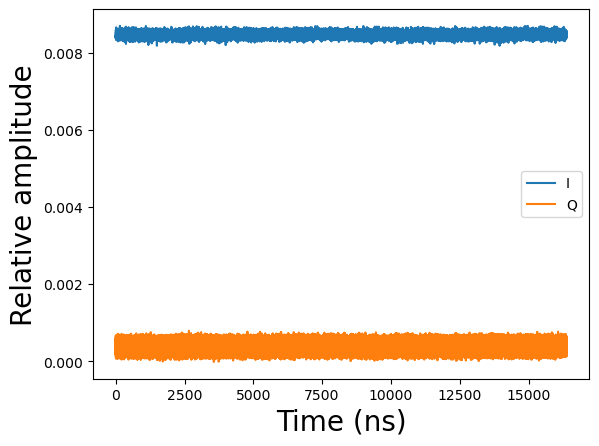

I Offset : 8.474 mV 
Q Offset : 0.390 mV


In [16]:
I_offset, Q_offset = acquire_scope_and_calc_offsets()

Correcting the Offsets
----------------------

One can correct for these offsets by changing the reference Voltage of the ADC. This can be done using the parameters <code>[QRM.in0_offset](https://qblox-qblox-instruments.readthedocs-hosted.com/en/main/api_reference/module.html#QRM.in0_offset)</code> and <code>[QRM.in1_offset](https://qblox-qblox-instruments.readthedocs-hosted.com/en/main/api_reference/module.html#QRM.in1_offset)</code>.

In [ ]:
adc_offset_path0(-I_offset)  # Negative sign to compensate for the offset
adc_offset_path1(-Q_offset)

Repeating the offset measurement as before, we get:

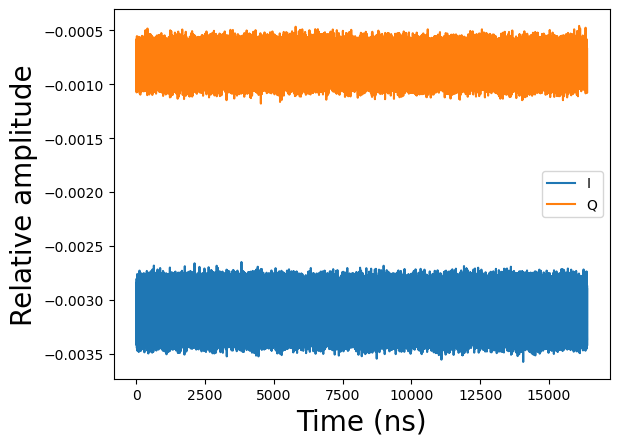

I Offset : -3.108 mV 
Q Offset : -0.807 mV


In [18]:
I_offset, Q_offset = acquire_scope_and_calc_offsets()

Advanced ADC Offset Calibration : Curve Fitting Method
------------------------------------------------------

As you may have noticed in the previous section, manually compensating for the offset does not entirely eliminate it, leaving some residual offset. This is because of the non-linear effects of these input offsets. To circumvent this, one can curve-fit the dependence of the set offset value on the actual offset value. In the following section, we do this by fitting 10 setpoints against the 10 measured offset values from the binned acquisition with a function. We then find the roots/zeros of this function to set the actual offset to zero.

In [19]:
# Define helper functions
def get_real_root(coeffs: np.array) -> np.array:
    for root in np.roots(coeffs):
        if root.imag == 0:
            output = root
    return np.real(output)


def get_curve(x: np.array, coeffs: np.array) -> np.array:
    y = 0
    for i, coeff in enumerate(coeffs):
        y += coeff * x ** (len(coeffs) - (i + 1))
    return y

In [20]:
# Define the program that we will run
seq_prog = """
      move    0,R0        #Loop iterator.
      nop

loop:
      move    100, R1     #Averages
avg_loop:
      acquire 0,R0,20000   #Acquire bins and store them in "non_weighed" acquisition.
      loop    R1, @avg_loop
      add     R0,1,R0     #Increment iterator
      nop                 #Wait a cycle for R0 to be available.
      jlt     R0,100,@loop #Run until number of iterations is done.

      stop                #Stop.
"""

In [21]:
# Add sequence program, waveforms, weights and acquisitions to single dictionary and write to JSON file.
sequence = {
    "waveforms": {},
    "weights": {},
    "acquisitions": acquisitions,
    "program": seq_prog,
}
with open("sequence.json", "w", encoding="utf-8") as file:
    json.dump(sequence, file, indent=4)
    file.close()

In [22]:
# Upload sequence.
module.sequencer0.sequence("sequence.json")

Let's start the sequence and retrieve the results.

In [23]:
# Set the domain (X) around these original offset values

I_offset_setpoints = np.linspace(-10e-3 + adc_offset_path0(), +10e-3 + adc_offset_path0(), 12)
Q_offset_setpoints = np.linspace(-10e-3 + adc_offset_path1(), +10e-3 + adc_offset_path1(), 12)

int_len = module.sequencer0.integration_length_acq()
I_offset_sum, Q_offset_sum = [], []

for I_offset_i, Q_offset_i in zip(I_offset_setpoints, Q_offset_setpoints):
    module.delete_acquisition_data(0, all=True)
    adc_offset_path0(I_offset_i)
    adc_offset_path1(Q_offset_i)
    module.arm_sequencer(0)
    module.start_sequencer()
    module.get_acquisition_status(0, 1)
    non_weighed_acq = module.get_acquisitions(0)["non_weighed"]
    I_offset_sum += [
        np.mean(non_weighed_acq["acquisition"]["bins"]["integration"]["path0"]) * 1e3 / int_len
    ]
    Q_offset_sum += [
        np.mean(non_weighed_acq["acquisition"]["bins"]["integration"]["path1"]) * 1e3 / int_len
    ]

output = {
    "offsets_I": I_offset_setpoints,
    "offsets_Q": Q_offset_setpoints,
    "I_m": I_offset_sum,
    "Q_m": Q_offset_sum,
}

Offset setpoints corresponding to observed zero offset: 
I offset: -5.935903882610491
Q offset: -0.04695613492097488


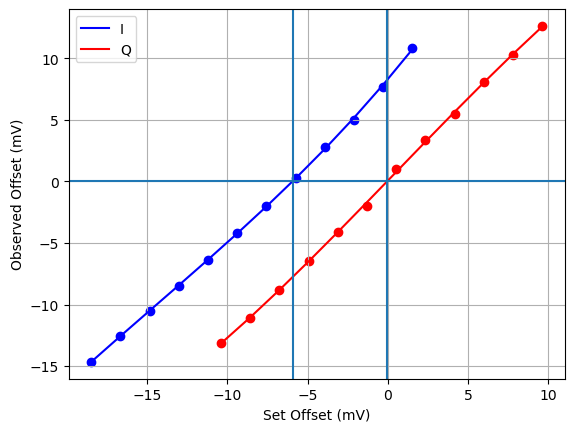

In [24]:
plt.figure()

## Fit I offset and find its root
coeffs = np.polyfit(np.array(output["offsets_I"]) * 1e3, np.array(output["I_m"]), 3)
new_I_offset = get_real_root(coeffs)

plt.plot(
    output["offsets_I"] * 1e3,
    get_curve(np.array(output["offsets_I"]) * 1e3, coeffs),
    c="b",
    label="I",
)
plt.scatter(output["offsets_I"] * 1e3, output["I_m"], c="b")

# Fit Q offset and find its root
coeffs = np.polyfit(np.array(output["offsets_Q"]) * 1e3, np.array(output["Q_m"]), 3)
new_Q_offset = get_real_root(coeffs)

plt.plot(
    output["offsets_Q"] * 1e3,
    get_curve(np.array(output["offsets_Q"]) * 1e3, coeffs),
    c="r",
    label="Q",
)
plt.scatter(output["offsets_Q"] * 1e3, output["Q_m"], c="r")

# Plot zeros on the plot
plt.axvline(x=new_I_offset)
plt.axvline(x=new_Q_offset)
plt.axhline(y=0)

plt.xlabel("Set Offset (mV)")
plt.ylabel("Observed Offset (mV)")
plt.legend()
plt.grid()
print(
    f"Offset setpoints corresponding to observed zero offset: \nI offset: {new_I_offset}\nQ offset: {new_Q_offset}"
)

Applying The Offset Corrections
-------------------------------

Using the zeros obtained from the curve fitting, we attempt to correct for the input offsets again:

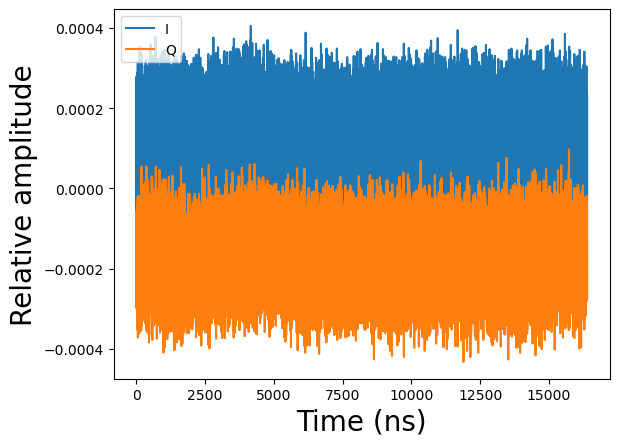

I Offset : 0.101 mV 
Q Offset : -0.170 mV


In [25]:
adc_offset_path0(new_I_offset * 1e-3)  # Multiplying by 1e-3 to convert to mV
adc_offset_path1(new_Q_offset * 1e-3)

I_offset_calib, Q_offset_calib = acquire_scope_and_calc_offsets()

In [27]:
print(new_I_offset * 1e-3)
print(new_Q_offset * 1e-3)

-0.005935903882610491
-4.695613492097489e-05


As you can see, you have calibrated away the offsets to sub-millivolt range, which is at the limit of the ADC resolution.

<div class="alert alert-success">
We advise you to check/calibrate these offset values every few days if they are vital for your experiments, especially when you are dealing with low input signals. </div>

Stop
----

Finally, let's stop the sequencers if they haven't already and close the instrument connection. One can also display a detailed snapshot containing the instrument parameters before
closing the connection by uncommenting the corresponding lines.

In [26]:
# Stop both sequencers.
module.stop_sequencer()

# Print status of both sequencers (should now say it is stopped).
print(module.get_sequencer_status(0))
print(module.get_sequencer_status(1))
print()

# Print an overview of the instrument parameters.
print("Snapshot:")
module.print_readable_snapshot(update=True)

# Reset the cluster
cluster.reset()
print(cluster.get_system_status())

Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, ACQ_SCOPE_DONE_PATH_0, ACQ_SCOPE_OVERWRITTEN_PATH_0, ACQ_SCOPE_DONE_PATH_1, ACQ_SCOPE_OVERWRITTEN_PATH_1, ACQ_BINNING_DONE, Warning Flags: NONE, Error Flags: NONE, Log: []
Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []

Snapshot:
cluster0_module4:
	parameter                    value
--------------------------------------------------------------------------------
in0_gain                      :	-6 (dB)
in0_offset                    :	-0.0059359 (V)
in1_gain                      :	-6 (dB)
in1_offset                    :	-4.6956e-05 (V)
marker0_exp0_config           :	bypassed 
marker0_exp1_config           :	bypassed 
marker0_exp2_config           :	bypassed 
marker0_exp3_config           :	bypassed 
marker0_fir_config            :	bypassed 
marker0_inv_en                :	False 
marker1_exp0_config           :	bypassed 
marker1_exp1_config           :	bypassed 
marker1_exp2_con